# LSTM

In [10]:
import urllib.request

url = "https://www.gutenberg.org/files/2701/2701-0.txt"
text = urllib.request.urlretrieve(url, "moby_dick.txt")
with open("moby_dick.txt", encoding="utf-8") as f:
    text = f.read()


start = text.find("*** START OF")
end = text.find("*** END OF")
text = text[text.find("\n", start):end]
text = text[27157::]

In [23]:
import numpy as np
from collections import Counter

text = text
text = text[:5000]

count = Counter(text)

chars = sorted(set(text))
vocab = {c: i for i, c in enumerate(chars)}
inv_vocab = {i: c for c, i in vocab.items()}
vocab_size = len(vocab)

encoded = np.array([vocab[c] for c in text])
onehot = np.eye(vocab_size)[encoded]

x = onehot[None, :-1]
y = onehot[None, 1:]

print(count)
print(f"Unique tokens: {vocab_size}")
print(f"Total tokens: {len(encoded)}")

Counter({' ': 815, 'e': 530, 't': 351, 'a': 291, 'o': 283, 's': 271, 'i': 264, 'n': 248, 'h': 235, 'r': 235, 'l': 176, 'd': 144, 'u': 113, 'm': 101, 'y': 97, 'f': 85, 'p': 81, '\n': 80, 'w': 78, 'g': 77, 'c': 75, ',': 59, 'b': 46, 'v': 42, '.': 38, 'k': 23, 'I': 15, '—': 13, 'W': 13, '?': 13, ';': 12, 'T': 11, 'S': 9, '-': 8, 'C': 7, 'z': 6, 'x': 6, 'B': 5, 'H': 4, 'A': 4, 'P': 4, 'N': 4, 'R': 3, 'L': 3, 'q': 3, '’': 3, 'G': 3, '!': 3, 'Y': 2, 'J': 2, 'E': 1, '1': 1, 'M': 1, 'j': 1, 'O': 1, 'D': 1})
Unique tokens: 56
Total tokens: 5000


In [13]:
from NNLibrary.network import Network
from NNLibrary.Layers.learnable import RNN, LSTM
from NNLibrary.Layers.activations import Sigmoid, Softmax

network = Network(
    layers=[
        LSTM(in_dim=vocab_size, hidden_dim=16, out_dim=vocab_size),
        # Sigmoid(),
        # Softmax(),
    ]
)

n_params = network.count_parameters()
print(f"Total parameter count: {n_params}")

Total parameter count: 5624


In [14]:
from NNLibrary.Layers.activations import Softmax

def sample_text(network, length=64, T=1, np_seed=None, seed=" "):
    np.random.seed(np_seed)
    softmax = Softmax(T=T)

    context = [onehot[vocab[seed]]] # List of one-hot

    out_seq = seed

    for _ in range(length):
        x_in = np.expand_dims(np.array(context), axis=0)
        logits = network.forward(x_in)
        pred = softmax.forward(logits)

        next_id = np.random.choice(vocab_size, p=pred[0, -1])
        next_ch = inv_vocab[next_id]

        out_seq += next_ch
        # print(onehot[inv_vocab[next_id]])
        context.append(onehot[next_id])

    print(out_seq)
    return out_seq

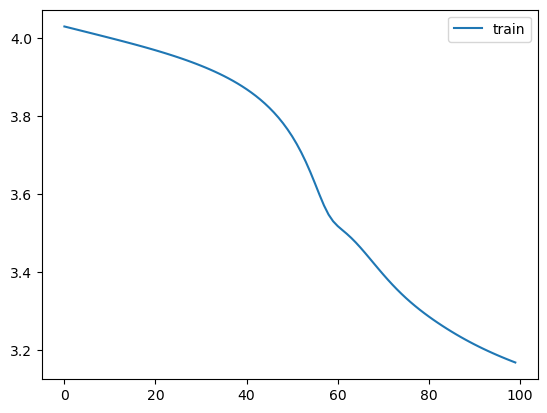

In [15]:
import matplotlib.pyplot as plt
from NNLibrary.Layers.loss import CrossEntropy, SoftmaxCE
from NNLibrary.optimizers import Adam, GradientDescent

epochs = 100
lr = 0.001

loss_fn = SoftmaxCE()
optimizer = Adam(lr, beta=0.9, gamma=0.999)
# optimizr = GradientDescent(lr=lr)

metrics = {"train": {"loss": [], "epoch": []}, "val": {"loss": [], "epoch": []}, "epochs": []}

for epoch in range(epochs):
    network.train()

    metrics["epochs"].append(epoch)

    out = network.forward(x)
    loss = loss_fn.forward(out, y)

    network.backprop(loss_fn, optimizer) # Backpropagation and weight updates
    
    metrics["train"]["loss"].append(loss)
    metrics["train"]["epoch"].append(epoch)

    # if epoch % 100 == 0:
    #     print(f"Epoch {epoch}")
    #     print(f"Loss: {loss}")
    #     out_seq = sample_text(network, T=0.1)


plt.plot(metrics["train"]["epoch"], metrics["train"]["loss"], label="train")
plt.legend()
plt.show()

In [20]:
out_seq = sample_text(network, length=64, T=0.1, seed=" ")

  oo n  n                                                        
